# 🏎️ Ferrari — Race Strategy Optimizer
## Notebook 3: XGBoost Pit Window Predictor

> **Input:** X_train.csv, y_train.csv, X_val.csv, y_val.csv from NB2
> **Output:** Trained model + SHAP plots + backtest results


In [1]:
# CELL 1: INSTALL & IMPORTS
!pip install optuna shap xgboost --quiet

import pandas as pd
import numpy as np
import os, json, pickle, warnings
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import shap
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, roc_curve
)
from sklearn.dummy import DummyClassifier

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

OUTPUT_DIR = '/kaggle/working/models'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'XGBoost : {xgb.__version__}')
print(f'Optuna  : {optuna.__version__}')
print(f'SHAP    : {shap.__version__}')


XGBoost : 3.1.3
Optuna  : 4.7.0
SHAP    : 0.50.0


In [2]:
# CELL 2: LOAD DATA

def find_file(filename):
    for root, dirs, files in os.walk('/kaggle/input/'):
        for f in files:
            if f == filename:
                path = os.path.join(root, f)
                print(f'   Found: {path}')
                return path
    fallback = f'/kaggle/working/data/{filename}'
    if os.path.exists(fallback):
        return fallback
    raise FileNotFoundError(f'Cannot find {filename}')

print('Loading data...')
X_train = pd.read_csv(find_file('X_train.csv'))
y_train = pd.read_csv(find_file('y_train.csv')).squeeze()
X_val   = pd.read_csv(find_file('X_val.csv'))
y_val   = pd.read_csv(find_file('y_val.csv')).squeeze()

try:
    with open(find_file('model_config.json')) as f:
        config = json.load(f)
    SCALE_POS_WEIGHT = config['scale_pos_weight']
    FEATURE_COLS     = config['feature_cols']
except:
    SCALE_POS_WEIGHT = 34
    FEATURE_COLS     = list(X_train.columns)

print(f'X_train          : {X_train.shape}')
print(f'X_val            : {X_val.shape}')
print(f'scale_pos_weight : {SCALE_POS_WEIGHT}')


Loading data...
   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/X_train.csv
   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/y_train.csv
   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/X_val.csv
   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/y_val.csv
   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/model_config.json
X_train          : (13380, 23)
X_val            : (4104, 23)
scale_pos_weight : 33.84


In [3]:
# CELL 3: BASELINE
# Always predicts no-pit. We must beat this.

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy     = dummy.predict(X_val)
baseline_f1 = f1_score(y_val, y_dummy, zero_division=0)

print(f'BASELINE F1       : {baseline_f1:.4f}  <- must beat this')
print(f'BASELINE Accuracy : {(y_dummy == y_val).mean()*100:.1f}%  <- meaningless here')
print(f'Target: F1 > 0.40 = good | F1 > 0.55 = great')


BASELINE F1       : 0.0000  <- must beat this
BASELINE Accuracy : 97.2%  <- meaningless here
Target: F1 > 0.40 = good | F1 > 0.55 = great


In [4]:
# CELL 4: XGBOOST V1
# scale_pos_weight=34 tells XGBoost: missing a pit lap is 34x worse.
# Without this, model ignores the minority class entirely.

xgb_v1 = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = SCALE_POS_WEIGHT,
    eval_metric       = 'logloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

print('Training XGBoost v1...')
xgb_v1.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_v1 = xgb_v1.predict(X_val)
y_prob_v1 = xgb_v1.predict_proba(X_val)[:, 1]
f1_v1     = f1_score(y_val, y_pred_v1, zero_division=0)
roc_v1    = roc_auc_score(y_val, y_prob_v1)

print(f'\nXGBOOST V1:')
print(f'  F1      : {f1_v1:.4f}  (baseline: {baseline_f1:.4f})')
print(f'  ROC-AUC : {roc_v1:.4f}')
print(classification_report(y_val, y_pred_v1, target_names=['Stay Out','Pit'], zero_division=0))


Training XGBoost v1...

XGBOOST V1:
  F1      : 0.7719  (baseline: 0.0000)
  ROC-AUC : 0.9835
              precision    recall  f1-score   support

    Stay Out       0.99      0.99      0.99      3989
         Pit       0.78      0.77      0.77       115

    accuracy                           0.99      4104
   macro avg       0.89      0.88      0.88      4104
weighted avg       0.99      0.99      0.99      4104



In [5]:
# CELL 5: OPTUNA TUNING
# Optuna tries 50 hyperparameter combinations using Bayesian optimisation.
# Smarter than grid search - focuses on promising regions automatically.
# Takes ~3-5 mins on Kaggle CPU.

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 9),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'scale_pos_weight' : SCALE_POS_WEIGHT,
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbosity'        : 0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, verbose=False)
    return f1_score(y_val, model.predict(X_val), zero_division=0)

print('Running Optuna 50 trials (~3-5 mins)...')
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params.copy()
best_params.update({'scale_pos_weight':SCALE_POS_WEIGHT,'eval_metric':'logloss',
                    'random_state':42,'n_jobs':-1,'verbosity':0})

print(f'Best F1 : {study.best_value:.4f}')


Running Optuna 50 trials (~3-5 mins)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best F1 : 0.8250


In [6]:
# CELL 6: FINAL MODEL

print('Training final model with best params...')
final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_pred_final = final_model.predict(X_val)
y_prob_final = final_model.predict_proba(X_val)[:, 1]
f1_final     = f1_score(y_val, y_pred_final, zero_division=0)
roc_final    = roc_auc_score(y_val, y_prob_final)

print(f'FINAL MODEL:')
print(f'  F1      : {f1_final:.4f}  (v1: {f1_v1:.4f} | baseline: {baseline_f1:.4f})')
print(f'  ROC-AUC : {roc_final:.4f}')
print(classification_report(y_val, y_pred_final, target_names=['Stay Out','Pit'], zero_division=0))


Training final model with best params...
FINAL MODEL:
  F1      : 0.8250  (v1: 0.7719 | baseline: 0.0000)
  ROC-AUC : 0.9924
              precision    recall  f1-score   support

    Stay Out       1.00      0.99      0.99      3989
         Pit       0.79      0.86      0.82       115

    accuracy                           0.99      4104
   macro avg       0.89      0.93      0.91      4104
weighted avg       0.99      0.99      0.99      4104



Default (0.50)       F1: 0.8250
Optimal (0.54)  F1: 0.8426
Using threshold = 0.54


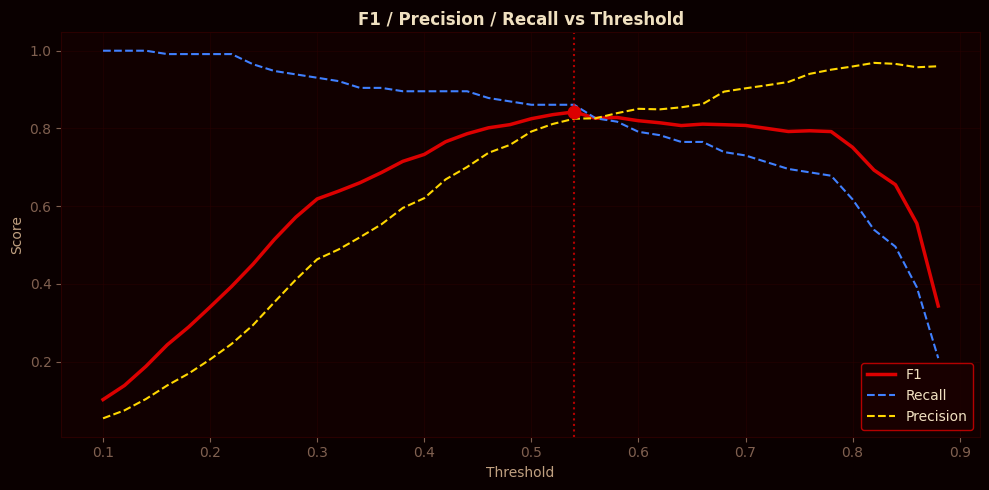

In [7]:
# CELL 7: THRESHOLD OPTIMISATION
# Default is 0.5 but we tune it to maximise F1.

thresholds  = np.arange(0.1, 0.9, 0.02)
f1_scores   = [f1_score(y_val,(y_prob_final>=t).astype(int),zero_division=0) for t in thresholds]
rec_scores  = [recall_score(y_val,(y_prob_final>=t).astype(int),zero_division=0) for t in thresholds]
prec_scores = [precision_score(y_val,(y_prob_final>=t).astype(int),zero_division=0) for t in thresholds]

best_thresh_idx = np.argmax(f1_scores)
BEST_THRESHOLD  = thresholds[best_thresh_idx]
best_f1_thresh  = f1_scores[best_thresh_idx]
y_pred_thresh   = (y_prob_final >= BEST_THRESHOLD).astype(int)

print(f'Default (0.50)       F1: {f1_final:.4f}')
print(f'Optimal ({BEST_THRESHOLD:.2f})  F1: {best_f1_thresh:.4f}')
print(f'Using threshold = {BEST_THRESHOLD:.2f}')

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0A0000')
ax.set_facecolor('#110000')
ax.grid(color='#2A0000', alpha=0.5)
ax.plot(thresholds, f1_scores,   color='#DC0000', lw=2.5, label='F1')
ax.plot(thresholds, rec_scores,  color='#4080FF', lw=1.5, label='Recall', linestyle='--')
ax.plot(thresholds, prec_scores, color='#FFD700', lw=1.5, label='Precision', linestyle='--')
ax.axvline(BEST_THRESHOLD, color='#DC0000', linestyle=':', alpha=0.8)
ax.scatter([BEST_THRESHOLD],[best_f1_thresh], color='#DC0000', s=80, zorder=5)
ax.set_xlabel('Threshold', color='#C0A080')
ax.set_ylabel('Score', color='#C0A080')
ax.set_title('F1 / Precision / Recall vs Threshold', color='#F0E0C0', fontweight='bold')
ax.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
ax.tick_params(colors='#806050')
for spine in ax.spines.values(): spine.set_color('#2A0000')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/threshold_curve.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()


Computing SHAP values (~1 min)...


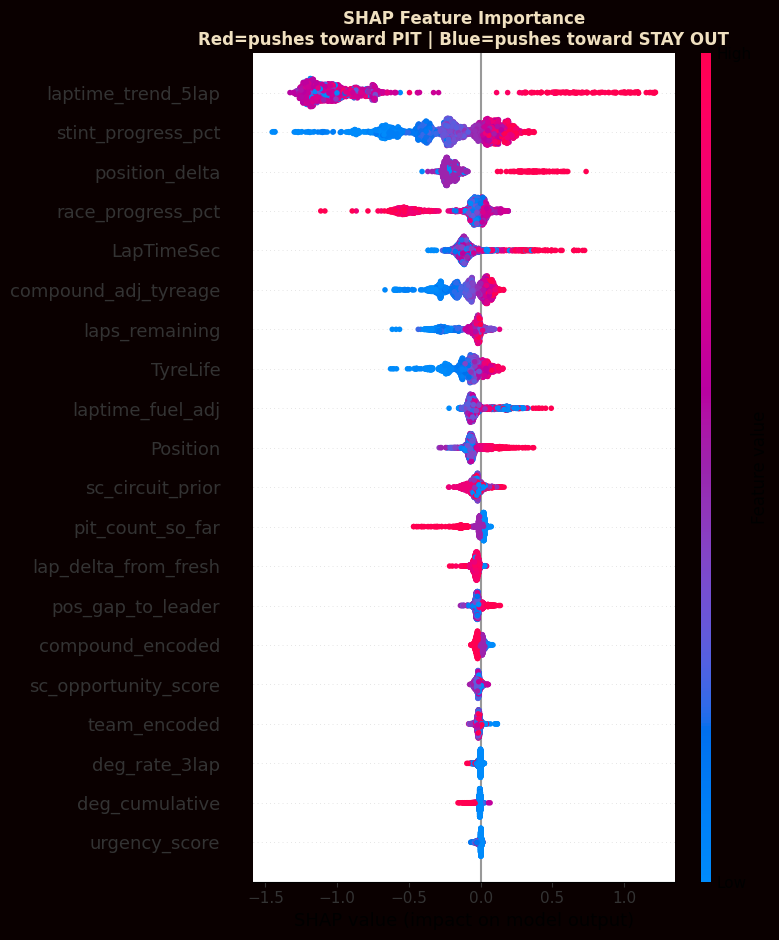

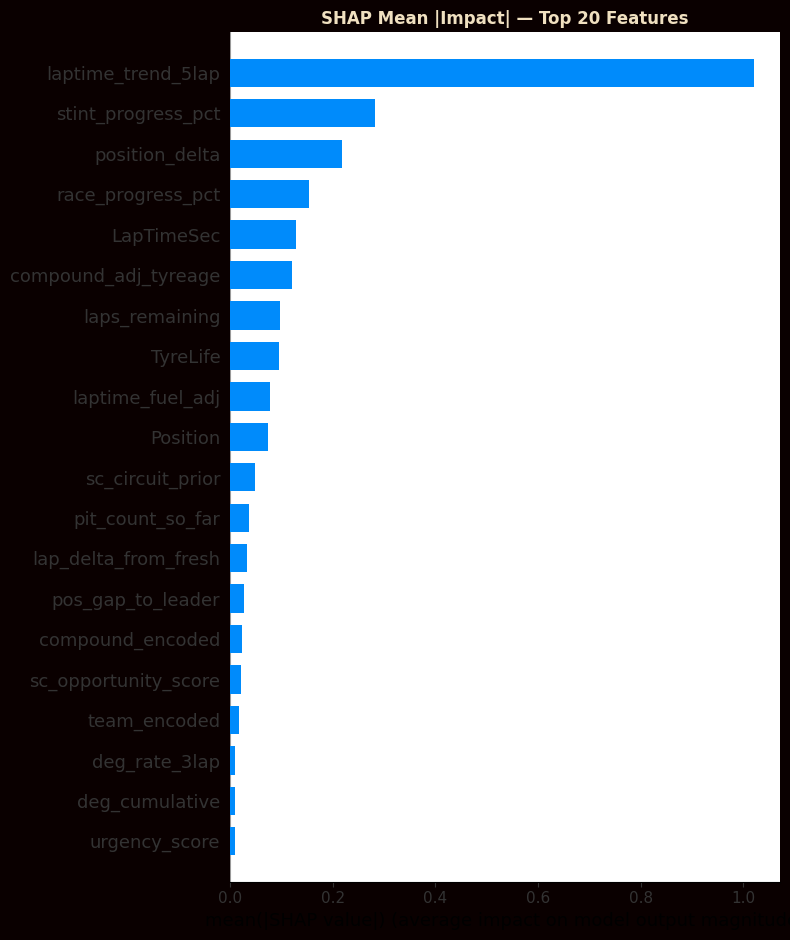

SHAP plots saved


In [8]:
# CELL 8: SHAP
# SHAP explains WHY the model made each prediction.
# This is your resume differentiator - explainable AI on real F1 data.

print('Computing SHAP values (~1 min)...')
X_shap      = X_val.sample(min(2000, len(X_val)), random_state=42)
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
plt.gcf().patch.set_facecolor('#0A0000')
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False, max_display=20)
plt.title('SHAP Feature Importance\nRed=pushes toward PIT | Blue=pushes toward STAY OUT',
          color='#F0E0C0', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_summary.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()

plt.figure(figsize=(10, 7))
plt.gcf().patch.set_facecolor('#0A0000')
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Mean |Impact| — Top 20 Features', color='#F0E0C0', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/shap_bar.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('SHAP plots saved')


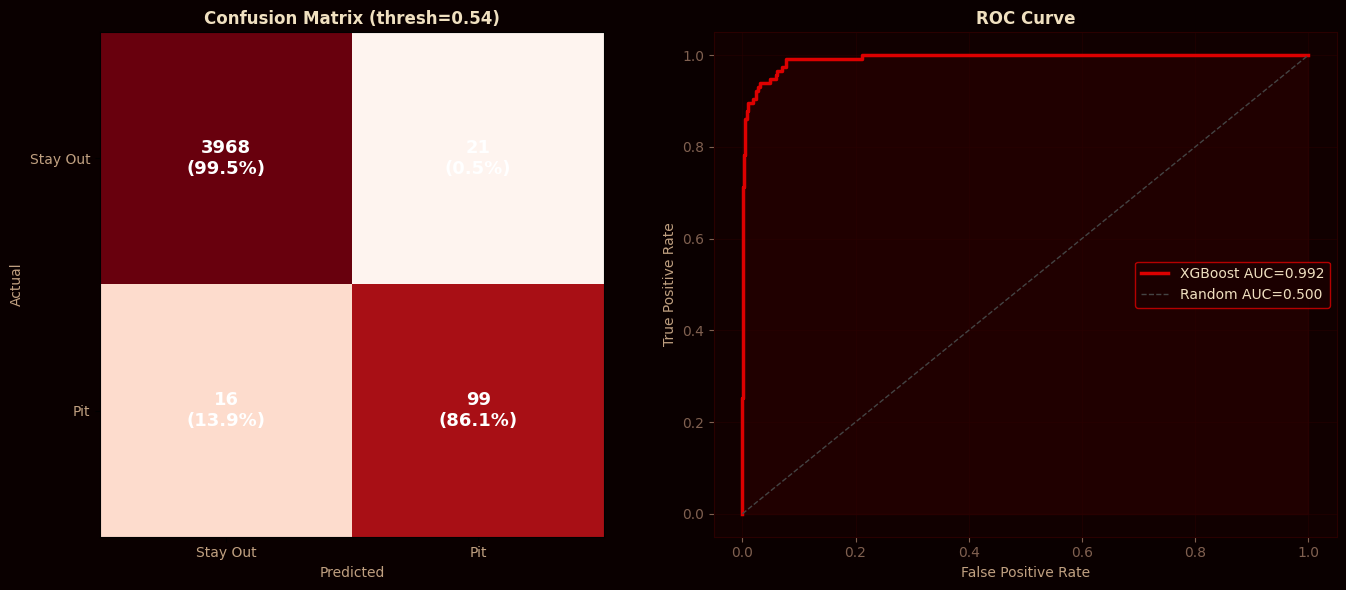

In [9]:
# CELL 9: CONFUSION MATRIX + ROC

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0A0000')

ax1 = axes[0]
ax1.set_facecolor('#110000')
cm      = confusion_matrix(y_val, y_pred_thresh)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
ax1.imshow(cm_norm, cmap='Reds', vmin=0, vmax=1)
ax1.set_xticks([0,1]); ax1.set_yticks([0,1])
ax1.set_xticklabels(['Stay Out','Pit'], color='#C0A080')
ax1.set_yticklabels(['Stay Out','Pit'], color='#C0A080')
ax1.set_xlabel('Predicted', color='#C0A080')
ax1.set_ylabel('Actual', color='#C0A080')
ax1.set_title(f'Confusion Matrix (thresh={BEST_THRESHOLD:.2f})', color='#F0E0C0', fontweight='bold')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)',
                 ha='center', va='center', color='white', fontsize=13, fontweight='bold')

ax2 = axes[1]
ax2.set_facecolor('#110000')
ax2.grid(color='#2A0000', alpha=0.5)
fpr, tpr, _ = roc_curve(y_val, y_prob_final)
ax2.plot(fpr, tpr, color='#DC0000', lw=2.5, label=f'XGBoost AUC={roc_final:.3f}')
ax2.plot([0,1],[0,1], color='#444', linestyle='--', lw=1, label='Random AUC=0.500')
ax2.fill_between(fpr, tpr, alpha=0.08, color='#DC0000')
ax2.set_xlabel('False Positive Rate', color='#C0A080')
ax2.set_ylabel('True Positive Rate', color='#C0A080')
ax2.set_title('ROC Curve', color='#F0E0C0', fontweight='bold')
ax2.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0')
ax2.tick_params(colors='#806050')
for spine in ax2.spines.values(): spine.set_color('#2A0000')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/evaluation_plots.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()


In [10]:
# CELL 10: RACE BACKTEST
# Replay each 2025 race lap by lap, compare model vs actual team decisions.
# Headline metric: X% of real pit windows detected.

val_full           = pd.read_csv(find_file('val_engineered.csv'))
available_features = [c for c in FEATURE_COLS if c in val_full.columns]
X_val_full         = val_full[available_features].fillna(0)

val_full['pit_probability'] = final_model.predict_proba(X_val_full)[:, 1]
val_full['model_pit_call']  = (val_full['pit_probability'] >= BEST_THRESHOLD).astype(int)

backtest_results = []
for gp in val_full['GrandPrix'].unique():
    for driver in val_full[val_full['GrandPrix']==gp]['Driver'].unique():
        drv = val_full[(val_full['GrandPrix']==gp) & (val_full['Driver']==driver)]
        if len(drv) < 5: continue
        backtest_results.append({
            'GrandPrix'    : gp,
            'Driver'       : driver,
            'ActualPits'   : int(drv['DidPit'].sum()),
            'ModelPits'    : int(drv['model_pit_call'].sum()),
            'CorrectCalls' : int(((drv['model_pit_call']==1)&(drv['DidPit']==1)).sum()),
            'MissedPits'   : int(((drv['model_pit_call']==0)&(drv['DidPit']==1)).sum()),
            'FalseAlarms'  : int(((drv['model_pit_call']==1)&(drv['DidPit']==0)).sum()),
        })

backtest_df    = pd.DataFrame(backtest_results)
total_pits     = backtest_df['ActualPits'].sum()
total_correct  = backtest_df['CorrectCalls'].sum()
total_missed   = backtest_df['MissedPits'].sum()
total_false    = backtest_df['FalseAlarms'].sum()
detection_rate = total_correct / total_pits * 100 if total_pits > 0 else 0

print('BACKTEST — 2025 VALIDATION RACES')
print('='*45)
print(f'  Actual pit stops  : {total_pits}')
print(f'  Correctly called  : {total_correct}  ({detection_rate:.1f}%)')
print(f'  Missed windows    : {total_missed}')
print(f'  False alarms      : {total_false}')
print(f'\n  HEADLINE METRIC: {detection_rate:.1f}% pit window detection rate')


   Found: /kaggle/input/notebooks/adityasharma100203/f1-strategy-notebook2-featureengineering/data/val_engineered.csv
BACKTEST — 2025 VALIDATION RACES
  Actual pit stops  : 114
  Correctly called  : 98  (86.0%)
  Missed windows    : 16
  False alarms      : 23

  HEADLINE METRIC: 86.0% pit window detection rate


Visualising: Bahrain — ANT


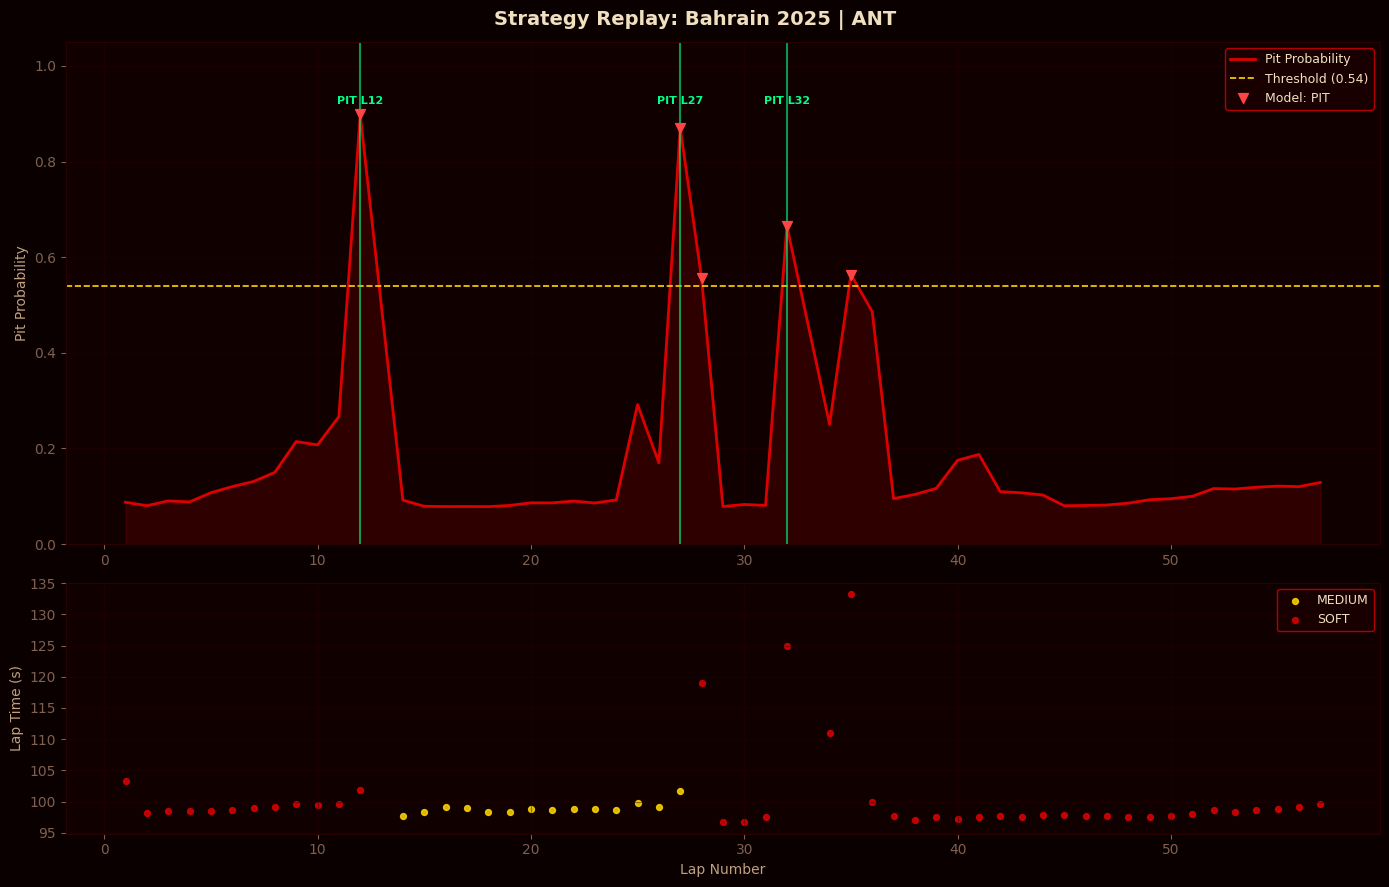

Saved: backtest_replay.png — your README hero image!


In [11]:
# CELL 11: BACKTEST VISUALISATION
# Pit probability trace over a real 2025 race. README hero image.

best_gp    = backtest_df.groupby('GrandPrix')['CorrectCalls'].sum().idxmax()
gp_sub     = backtest_df[(backtest_df['GrandPrix']==best_gp)&(backtest_df['ActualPits']>0)]
viz_driver = gp_sub.nlargest(1,'CorrectCalls')['Driver'].values[0] if len(gp_sub) else val_full['Driver'].iloc[0]
viz_data   = val_full[(val_full['GrandPrix']==best_gp)&(val_full['Driver']==viz_driver)].sort_values('LapNumber')

print(f'Visualising: {best_gp} — {viz_driver}')

fig, axes = plt.subplots(2,1,figsize=(14,9),gridspec_kw={'height_ratios':[2,1]})
fig.patch.set_facecolor('#0A0000')
fig.suptitle(f'Strategy Replay: {best_gp} 2025 | {viz_driver}', color='#F0E0C0', fontsize=14, fontweight='bold')

ax1 = axes[0]
ax1.set_facecolor('#110000')
ax1.grid(color='#2A0000', alpha=0.4)
laps, prob = viz_data['LapNumber'].values, viz_data['pit_probability'].values
ax1.fill_between(laps, prob, alpha=0.15, color='#DC0000')
ax1.plot(laps, prob, color='#DC0000', lw=2, label='Pit Probability')
ax1.axhline(BEST_THRESHOLD, color='#FFD700', linestyle='--', lw=1.2, label=f'Threshold ({BEST_THRESHOLD:.2f})')
for _, pit in viz_data[viz_data['DidPit']==1].iterrows():
    ax1.axvline(pit['LapNumber'], color='#00FF88', alpha=0.6, lw=1.5)
    ax1.text(pit['LapNumber'], 0.92, f"PIT L{int(pit['LapNumber'])}", ha='center', color='#00FF88', fontsize=8, fontweight='bold')
model_calls = viz_data[viz_data['model_pit_call']==1]
ax1.scatter(model_calls['LapNumber'], model_calls['pit_probability'], color='#FF4444', s=50, zorder=5, label='Model: PIT', marker='v')
ax1.set_ylabel('Pit Probability', color='#C0A080')
ax1.set_ylim(0, 1.05)
ax1.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0', fontsize=9)
ax1.tick_params(colors='#806050')
for spine in ax1.spines.values(): spine.set_color('#2A0000')

ax2 = axes[1]
ax2.set_facecolor('#110000')
ax2.grid(color='#2A0000', alpha=0.4)
for compound, grp in viz_data.groupby('Compound'):
    colors = {'SOFT':'#DC0000','MEDIUM':'#FFD700','HARD':'#E0E0E0'}
    ax2.scatter(grp['LapNumber'], grp['LapTimeSec'], color=colors.get(compound,'#888'), s=18, label=compound, alpha=0.85)
ax2.set_xlabel('Lap Number', color='#C0A080')
ax2.set_ylabel('Lap Time (s)', color='#C0A080')
ax2.legend(facecolor='#1A0000', edgecolor='#DC0000', labelcolor='#F0E0C0', fontsize=9)
ax2.tick_params(colors='#806050')
for spine in ax2.spines.values(): spine.set_color('#2A0000')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/backtest_replay.png', dpi=150, bbox_inches='tight', facecolor='#0A0000')
plt.show()
print('Saved: backtest_replay.png — your README hero image!')


In [12]:
# CELL 12: SAVE MODEL

with open(f'{OUTPUT_DIR}/xgb_pit_predictor.pkl','wb') as f:
    pickle.dump(final_model, f)

final_model.save_model(f'{OUTPUT_DIR}/xgb_pit_predictor.json')

model_meta = {
    'model_type'       : 'XGBClassifier',
    'n_features'       : len(available_features),
    'feature_cols'     : available_features,
    'best_threshold'   : float(BEST_THRESHOLD),
    'scale_pos_weight' : SCALE_POS_WEIGHT,
    'best_params'      : {k:(round(v,6) if isinstance(v,float) else v) for k,v in study.best_params.items()},
    'val_metrics': {
        'f1'           : round(best_f1_thresh, 4),
        'roc_auc'      : round(roc_final, 4),
        'recall'       : round(recall_score(y_val,y_pred_thresh,zero_division=0), 4),
        'precision'    : round(precision_score(y_val,y_pred_thresh,zero_division=0), 4),
    },
    'backtest': {
        'detection_rate_pct': round(detection_rate, 1),
        'total_pits'        : int(total_pits),
        'correct_calls'     : int(total_correct),
        'missed'            : int(total_missed),
        'false_alarms'      : int(total_false),
    }
}

with open(f'{OUTPUT_DIR}/model_meta.json','w') as f:
    json.dump(model_meta, f, indent=2)

print('FILES SAVED TO /kaggle/working/models/')
print('  xgb_pit_predictor.pkl   <- load with pickle in dashboard')
print('  xgb_pit_predictor.json  <- portable XGBoost format')
print('  model_meta.json         <- all metrics and config')
print('  shap_summary.png        <- SHAP beeswarm')
print('  backtest_replay.png     <- README hero image')
print()
print('='*50)
print('NOTEBOOK 3 COMPLETE')
print('='*50)
print(f'F1 Score      : {best_f1_thresh:.4f}')
print(f'ROC-AUC       : {roc_final:.4f}')
print(f'Pit Detection : {detection_rate:.1f}% of real windows caught')
print()
print('NEXT: Notebook 4 - LSTM Tyre Degradation  <-- GPU ON for this one')
print('Forza Ferrari! 🔴')


FILES SAVED TO /kaggle/working/models/
  xgb_pit_predictor.pkl   <- load with pickle in dashboard
  xgb_pit_predictor.json  <- portable XGBoost format
  model_meta.json         <- all metrics and config
  shap_summary.png        <- SHAP beeswarm
  backtest_replay.png     <- README hero image

NOTEBOOK 3 COMPLETE
F1 Score      : 0.8426
ROC-AUC       : 0.9924
Pit Detection : 86.0% of real windows caught

NEXT: Notebook 4 - LSTM Tyre Degradation  <-- GPU ON for this one
Forza Ferrari! 🔴
